In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv('/content/creditcard.csv')

In [3]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

In [5]:
X.shape, y.shape

((284807, 30), (284807,))

In [6]:
df.Class.value_counts()

,count
Class,
0,284315
1,492


# Heavely Unbalanced dataSet
lets try it with simple isolation forest
and then we will solve it with `imblearn`'s SMOTE techniques and all

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state= 42)

In [9]:
iso.fit(X_train)

IsolationForest(contamination=0.01, n_estimators=200, random_state=42)

In [10]:
y_hat = iso.predict(X_test)

In [14]:
y_hat

array([-1,  1,  1, ...,  1,  1,  1])

In [15]:
y_test

,Class
43428,1
49906,0
29474,0
276481,0
278846,0
...,...
75723,0
252263,0
221246,0
81910,0


In [16]:
y_hat.shape, y_test.shape

((56962,), (56962,))

In [17]:
type(y_hat), type(y_test)

(numpy.ndarray, pandas.core.series.Series)

In [18]:
pd.Series(y_hat).value_counts()

,count
1,56364
-1,598


as you can see we have output in 2 values -1 and 1 for that we use values to convert values of -1 to 1 and 1 to 0

In [20]:
y_hat=np.where(y_hat==-1,1,0)

[[56864     0]
 [   98     0]]


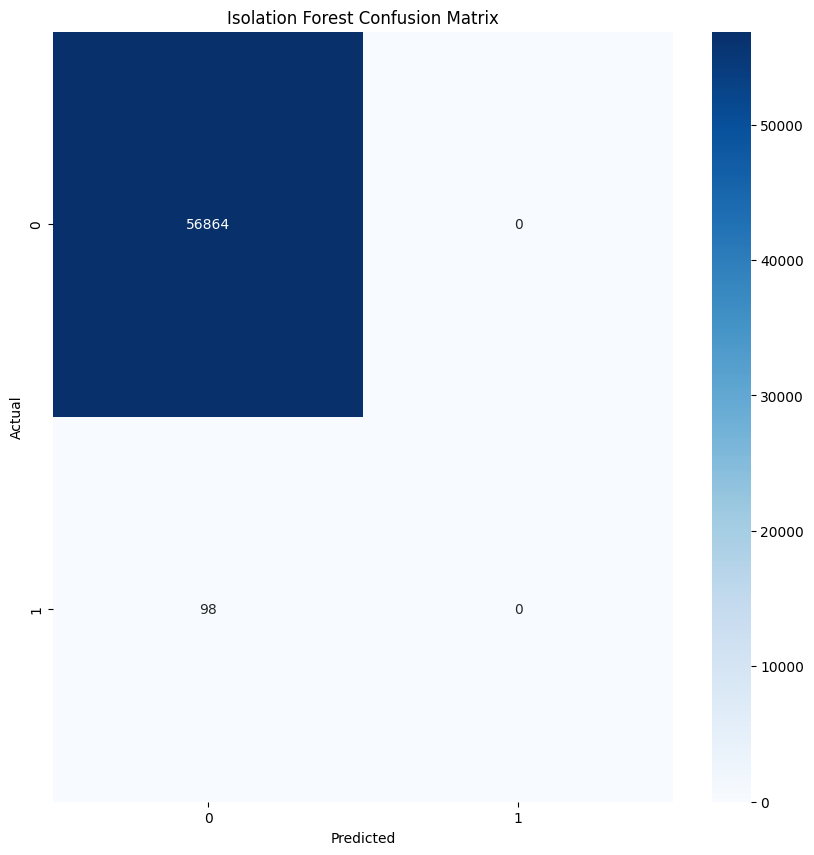

In [21]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
cm=confusion_matrix(y_test, y_hat)
print(cm)

plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',cmap = 'Blues')
plt.title('Isolation Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
